In [2]:
import pandas as pd  
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("../Data/final/environment_data.csv")

In [4]:
def detect_outliers_iqr(df, city=None):
    if city is not None:
        df = df[df["City"] == city]
    
    outlier_summary = []
    outlier_rows = pd.DataFrame()

    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        if col == "isWeekend" or col=="Electricity Consumption":
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outliers["Outlier_Feature"] = col   
        outlier_rows = pd.concat([outlier_rows, outliers])
        
        outlier_summary.append({
            "Feature": col,
            "Outliers_Count": len(outliers),
            "Lower_Bound": round(lower, 2),
            "Upper_Bound": round(upper, 2)
        })
    
    return pd.DataFrame(outlier_summary), outlier_rows



In [5]:
summary, outlier_rows = detect_outliers_iqr(df, city="Tokyo")
print(summary.sort_values(by="Outliers_Count", ascending=False))

             Feature  Outliers_Count  Lower_Bound  Upper_Bound
5                SO2              21       -37.88        88.24
3                NO2               8        -4.62       113.19
2                 O3               8       -22.06        83.44
0              PM2.5               7        -9.93        55.50
4                 CO               7        -3.94       629.23
1               PM10               5       -13.64        82.81
10        Wind_speed               3        -0.97        37.61
6        Green_Space               0       120.00       120.00
7   Temperature_mean               0        -8.84        45.91
8    Temperature_max               0        -6.00        50.00
9           Humidity               0        29.20       108.95
11          Pressure               0       993.58      1032.99


C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_9744\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_9744\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers["Outlier_Feature"] = col
C:\Users\AL SAAD NASR CITY\AppData\Local\Temp\ipykernel_9744\3679754261.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

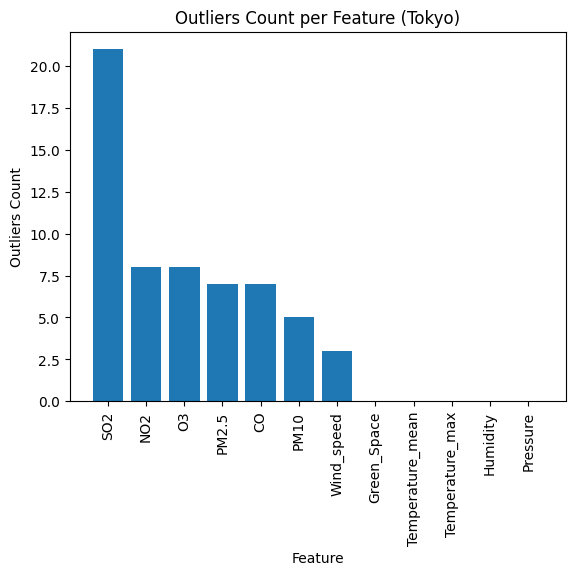

In [6]:

summary_sorted = summary.sort_values(by="Outliers_Count", ascending=False)

plt.figure()
plt.bar(summary_sorted["Feature"], summary_sorted["Outliers_Count"])
plt.xticks(rotation=90)
plt.xlabel("Feature")
plt.ylabel("Outliers Count")
plt.title("Outliers Count per Feature (Tokyo)")
plt.show()

In Tokyo, SO2 recorded the highest number of outliers, followed by other air pollution indicators such as NO2 and O3, suggesting that abnormal observations were mainly driven by fluctuations in air pollutant concentrations rather than weather-related factors.

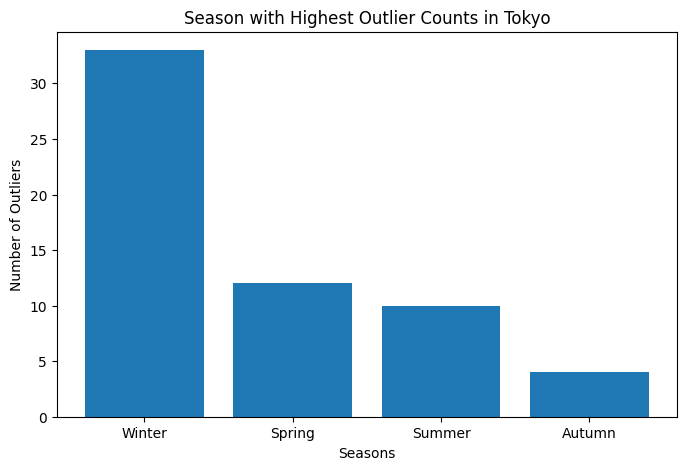

In [7]:
season_outliers = outlier_rows["Season"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(8,5))
plt.bar(season_outliers.index.astype(str), season_outliers.values)

plt.xlabel("Seasons")
plt.ylabel("Number of Outliers")
plt.title("Season with Highest Outlier Counts in Tokyo")

plt.show()

Winter recorded the highest number of outliers in Tokyo, indicating greater variability in environmental and pollution-related conditions during colder months. In contrast, Autumn showed the fewest outliers, suggesting more stable environmental conditions.

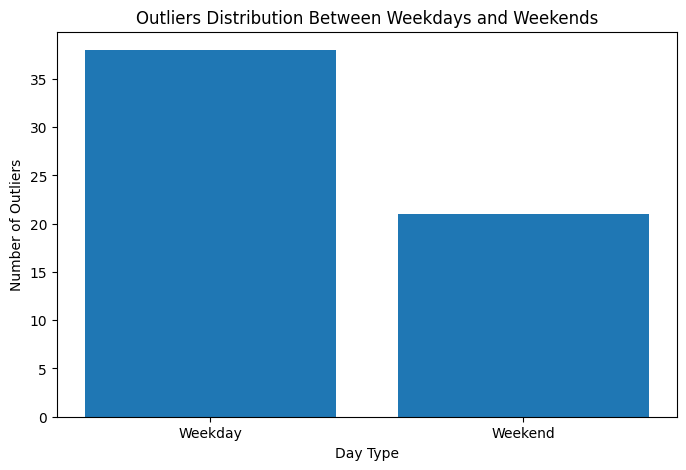

In [8]:
plt.figure(figsize=(8,5))
z=outlier_rows["isWeekend"].value_counts()
plt.bar(z.index.astype(str), z.values)

plt.xlabel("Day Type")
plt.ylabel("Number of Outliers")
plt.title("Outliers Distribution Between Weekdays and Weekends")

plt.xticks([0,1], ["Weekday", "Weekend"])

plt.show()

Severe pollution events in Nairobi appear to be more strongly associated with regular working days and daily human activities rather than weekends or holiday periods.

In [9]:
normal_rows = df[~df.index.isin(outlier_rows.index)]

outliers_mean = outlier_rows.mean(numeric_only=True)
normal_mean = normal_rows.mean(numeric_only=True)

comparison = pd.DataFrame({
    "Outliers": outliers_mean,
    "Normal": normal_mean
})

comparison

,Outliers,Normal
PM2.5,4.487154e+01,2.009100e+01
PM10,6.602881e+01,3.669048e+01
O3,3.144068e+01,5.483819e+01
NO2,7.408107e+01,3.239651e+01
CO,5.314774e+02,3.362348e+02
SO2,8.049739e+01,1.359188e+01
Green_Space,1.200000e+02,1.048846e+02
Temperature_mean,1.556950e+01,1.908209e+01
Temperature_max,1.900000e+01,2.332216e+01
Humidity,6.623022e+01,6.457851e+01


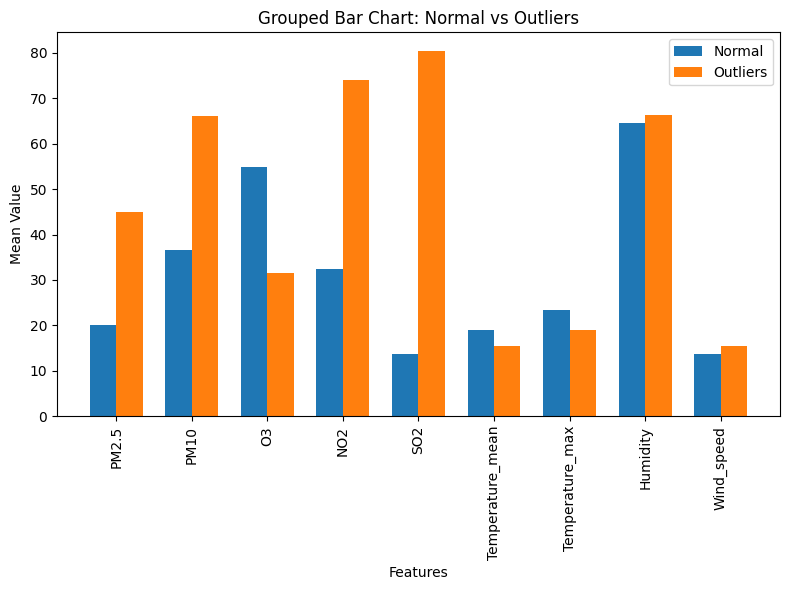

In [10]:

compare = comparison.drop(["Pressure", "isWeekend","CO","Electricity Consumption","Green_Space"])
features = compare.index

x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(
    x - width/2,
    compare["Normal"],
    width=width,
    label="Normal"
)

plt.bar(
    x + width/2,
    compare["Outliers"],
    width=width,
    label="Outliers"
)

plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")

plt.legend()

plt.tight_layout()

plt.show()

Outlier observations in Tokyo were strongly associated with significant increases in air pollutants such as SO2, NO2, PM10, and PM2.5, while weather-related variables remained relatively stable.

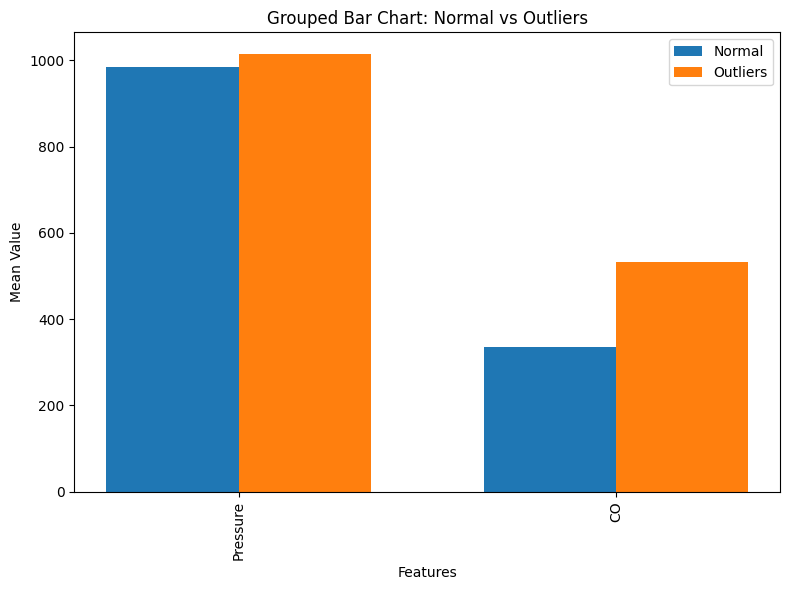

In [11]:
others= comparison.loc[["Pressure","CO"],:]
plt.figure(figsize=(8,6))
features=others.index
x=np.arange(len(features))
width=0.35
plt.bar(
    x-width/2,
    others["Normal"],
    width=width,
    label="Normal"
)
plt.bar(
    x+width/2,
    others["Outliers"],
    width=width,
    label="Outliers"
)
plt.xticks(x, features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Mean Value")
plt.title("Grouped Bar Chart: Normal vs Outliers")
plt.legend()
plt.tight_layout()
plt.show()

Outlier observations in Tokyo showed a noticeable increase in CO levels, while Pressure values remained relatively close to normal conditions.